### Imports

0.7.2
gpu
1.8786952
1.77213
0.9865036283644627


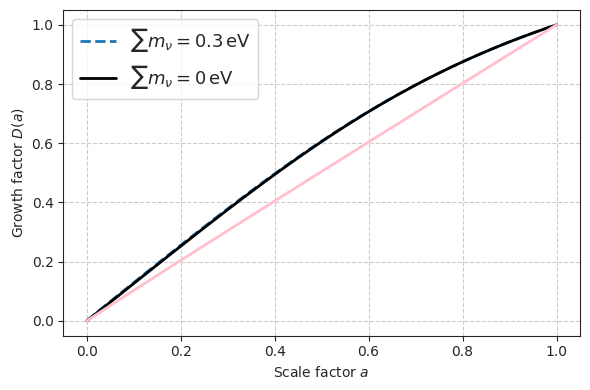

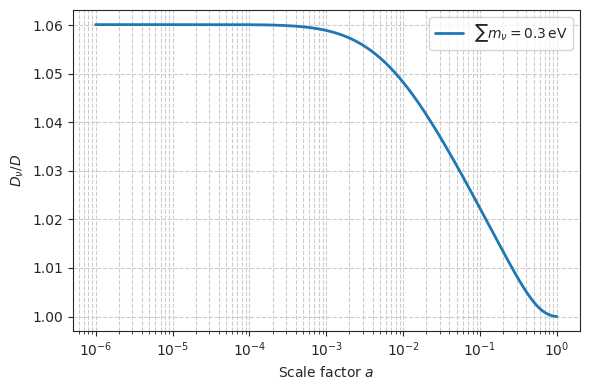

In [1]:
# Import modules
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
import jax.numpy as jnp
from discodj.cosmology.cosmology import Cosmology
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
#from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
#mpl.use("pgf")
#mpl.rcParams.update({
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "text.usetex": True,
#})

# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

# Scale factor
a = jnp.geomspace(1e-6, 1.0, 500)

# Cosmology sans neutrinos
cosmo = Cosmology(
    Omega_c=0.269984542,
    Omega_b=0.049,
    h=0.67,
    n_s=0.9667,
    sigma8=0.8159,
    mnu=jnp.asarray([0,0,0]) 
)

growth = cosmo.compute_unnormed_growth(a, 1e-6)

Norm_fact = growth["Dplus_unnormed_at_1"]
print(Norm_fact)
D1 = growth["Dplus"]  

# Stockage des résultats neutrinos
results = []


# Boucle neutrinos
for sum_masses in [0.3]:
    cosmo_nu = Cosmology(
        Omega_c=0.269984542,#-0.007175223208039425,
        Omega_b=0.049,
        h=0.67,
        n_s=0.9667,
        sigma8=0.8159,
        mnu=jnp.asarray([sum_masses/3,sum_masses/3,sum_masses/3] )
    )

    growth_nu = cosmo_nu.compute_unnormed_growth(a, 1e-6)

    Norm_fact_nu = growth_nu["Dplus_unnormed_at_1"]
    print(Norm_fact_nu)
    D1_nu = growth_nu["Dplus"]

    results.append((sum_masses, D1_nu))


f_nu =  0.007175223208039425 / (0.269984542+0.049)

# ===== PLOT 1 : D(a)
plt.figure(figsize=(6,4))

for sum_masses, D1_nu in results:
    plt.plot(a, D1_nu, '--', lw=2,
             label=fr"$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$")

plt.plot(a, D1, color='black', lw=2, label=r"$\sum m_\nu = 0\,\mathrm{{eV}}$")
plt.plot(a, a**(1-(3/5)*f_nu), color='pink', lw=2,)
print((1-(3/5)*f_nu))

plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'Growth factor $D(a)$')
plt.legend(prop={'size': 13})
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('D_DJ.pgf')

# ===== PLOT 2 : ratio
plt.figure(figsize=(6,4))

for sum_masses, D1_nu in results:
    plt.semilogx(a, D1_nu / D1, lw=2,
                 label=fr"$\sum m_\nu = {sum_masses}\,\mathrm{{eV}}$")

plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$D_{\nu}/D$')
plt.legend(prop={'size': 10})
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

#plt.savefig('Ddiff_DJ.pgf')

In [2]:
print((D1_nu[-1]/D1[-1])**2)

1.0


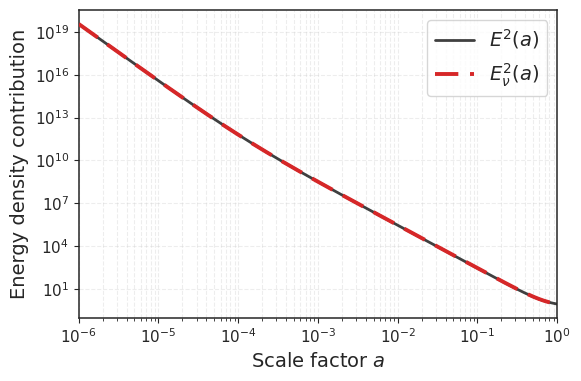

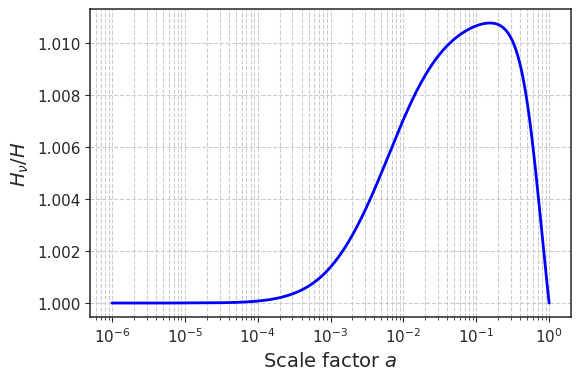

In [3]:
a = jnp.geomspace(1e-6, 1.0, 500)
H = cosmo.H(a)
H_nu = cosmo_nu.H(a)
H0 = 70
#Plot H vs H_wnu

# Style global
mpl.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.1,
})

fig, ax = plt.subplots(figsize=(6, 4))
# Courbe principale
ax.loglog(
    a, (H/H0)**2,
    color='black',
    lw=2.0,
    alpha=0.75,
    label=r'$E^2(a)$',
    zorder=2
)
# Courbe avec neutrinos mise en avant
ax.loglog(
    a, (H_nu/H0)**2,
    color='#d62728',
    lw=2.8,
    ls=(0, (6, 3)),
    label=r'$E_\nu^2(a)$',
    zorder=10
)
# Labels
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'Energy density contribution')

# Grid
ax.grid(
    True,
    which='both',
    ls='--',
    alpha=0.35
)

# Legend
ax.legend(
prop={'size': 14}
)

# Margins
ax.set_xlim(a.min(), a.max())
plt.tight_layout()
plt.show()
#plt.savefig('H_DJ.pgf')


#Plot relative deviation [(H_wnu/H)-1]
plt.figure(figsize=(6, 4))
plt.semilogx(a, abs(H_nu/H),color='blue',lw=2)  
plt.xlabel(r'Scale factor $a$')
plt.ylabel(r'$H_{\nu}/H$')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()
#plt.savefig('Hdiff_DJ.pgf')
